# 🎙️ Módulo de Habla — Versión Mejorada

Este notebook incorpora las siguientes mejoras respecto a la versión original:

| Mejora | Descripción |
|---|---|
| `extract_features_v3` | Mel Spectrogram (128 bandas), ZCR, Spectral Contrast, 26 MFCCs |
| Aumentación extendida | 9 variantes por audio (vs 3 originales) |
| XGBoost + Ensemble | Clasificadores más potentes que SVM solo |
| RandomizedSearchCV | Búsqueda de hiperparámetros más eficiente |
| `predict_from_raw_audio` | Función para probar con cualquier archivo de audio |

## 1. Instalación de Dependencias

In [1]:
!pip install -q librosa soundfile scikit-learn imbalanced-learn xgboost gradio joblib gdown seaborn matplotlib pandas numpy requests

In [2]:
!pip install -q smote-variants

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.8/417.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 2.2 MB/s eta 0:00:00


## 2. Importación de Librerías

In [3]:
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import gradio as gr
import os
import random
import seaborn as sns
import joblib
import requests
import warnings

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline as SKPipeline
from imblearn.over_sampling import SMOTE
from scipy.stats import loguniform
from IPython.display import display
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder


## 3. Descarga y Descompresión del Dataset

In [4]:
def descargar_zip_publico_drive(id_archivo, nombre_salida):
    url_base = "https://drive.usercontent.google.com/download"
    parametros = {
        'id': id_archivo,
        'export': 'download',
        'confirm': 't'
    }
    print("Iniciando descarga desde Google Drive...")
    sesion = requests.Session()
    respuesta = sesion.get(url_base, params=parametros, stream=True)

    if respuesta.status_code == 200:
        with open(nombre_salida, "wb") as f:
            for fragmento in respuesta.iter_content(chunk_size=32768):
                if fragmento:
                    f.write(fragmento)
        print(f"✅ Archivo '{nombre_salida}' descargado correctamente.")
    else:
        print(f"❌ Error en la descarga. Código: {respuesta.status_code}")

id_del_archivo = "1VHAqAuqCXLi_TOUS0SisZPYpXXIqGxOa"
descargar_zip_publico_drive(id_del_archivo, "dataset.zip")

print("Descomprimiendo archivo...")
!unzip -q -o dataset.zip -d /content/dataset_extraido
print("✅ Dataset disponible en /content/dataset_extraido")

Iniciando descarga desde Google Drive...
✅ Archivo 'dataset.zip' descargado correctamente.
Descomprimiendo archivo...
✅ Dataset disponible en /content/dataset_extraido


## 4. Carga de Rutas del Dataset

In [5]:
DATASET_PATH = "/content/dataset_extraido/dataset"
print("Carpetas encontradas en el dataset:", os.listdir(DATASET_PATH))

data = []
module_file_counts = {} # To track files per module

for module in os.listdir(DATASET_PATH):
    module_path = os.path.join(DATASET_PATH, module)
    if os.path.isdir(module_path):
        module_file_counts[module] = 0
        print(f"  Processing module: {module}")
        for label in os.listdir(module_path):
            label_path = os.path.join(module_path, label)
            if os.path.isdir(label_path):
                for file in os.listdir(label_path):
                    if file.endswith(".wav"):
                        file_path = os.path.join(label_path, file)
                        data.append({"module": module, "label": label, "path": file_path})
                        module_file_counts[module] += 1
            else:
                print(f"    Skipping non-directory: {label_path}")
    else:
        print(f"  Skipping non-directory: {module_path}")

df = pd.DataFrame(data)
print(f"DataFrame creado con {len(df)} registros.")
print("Files processed per module:")
for module, count in module_file_counts.items():
    print(f"  {module}: {count} files")

print("Unique modules in DataFrame:", df['module'].unique())
df.head()

Carpetas encontradas en el dataset: ['Multimedia_', 'Accesibilidad_', 'Activacion_', 'Navegacion_', 'Web_']
  Processing module: Multimedia_
  Processing module: Accesibilidad_
  Processing module: Activacion_
  Processing module: Navegacion_
  Processing module: Web_
DataFrame creado con 300 registros.
Files processed per module:
  Multimedia_: 64 files
  Accesibilidad_: 46 files
  Activacion_: 64 files
  Navegacion_: 64 files
  Web_: 62 files
Unique modules in DataFrame: ['Multimedia_' 'Accesibilidad_' 'Activacion_' 'Navegacion_' 'Web_']


,module,label,path
0,Multimedia_,Anterior,/content/dataset_extraido/dataset/Multimedia_/...
1,Multimedia_,Anterior,/content/dataset_extraido/dataset/Multimedia_/...
2,Multimedia_,Anterior,/content/dataset_extraido/dataset/Multimedia_/...
3,Multimedia_,Anterior,/content/dataset_extraido/dataset/Multimedia_/...
4,Multimedia_,Anterior,/content/dataset_extraido/dataset/Multimedia_/...


## Visualizacion de Dataset

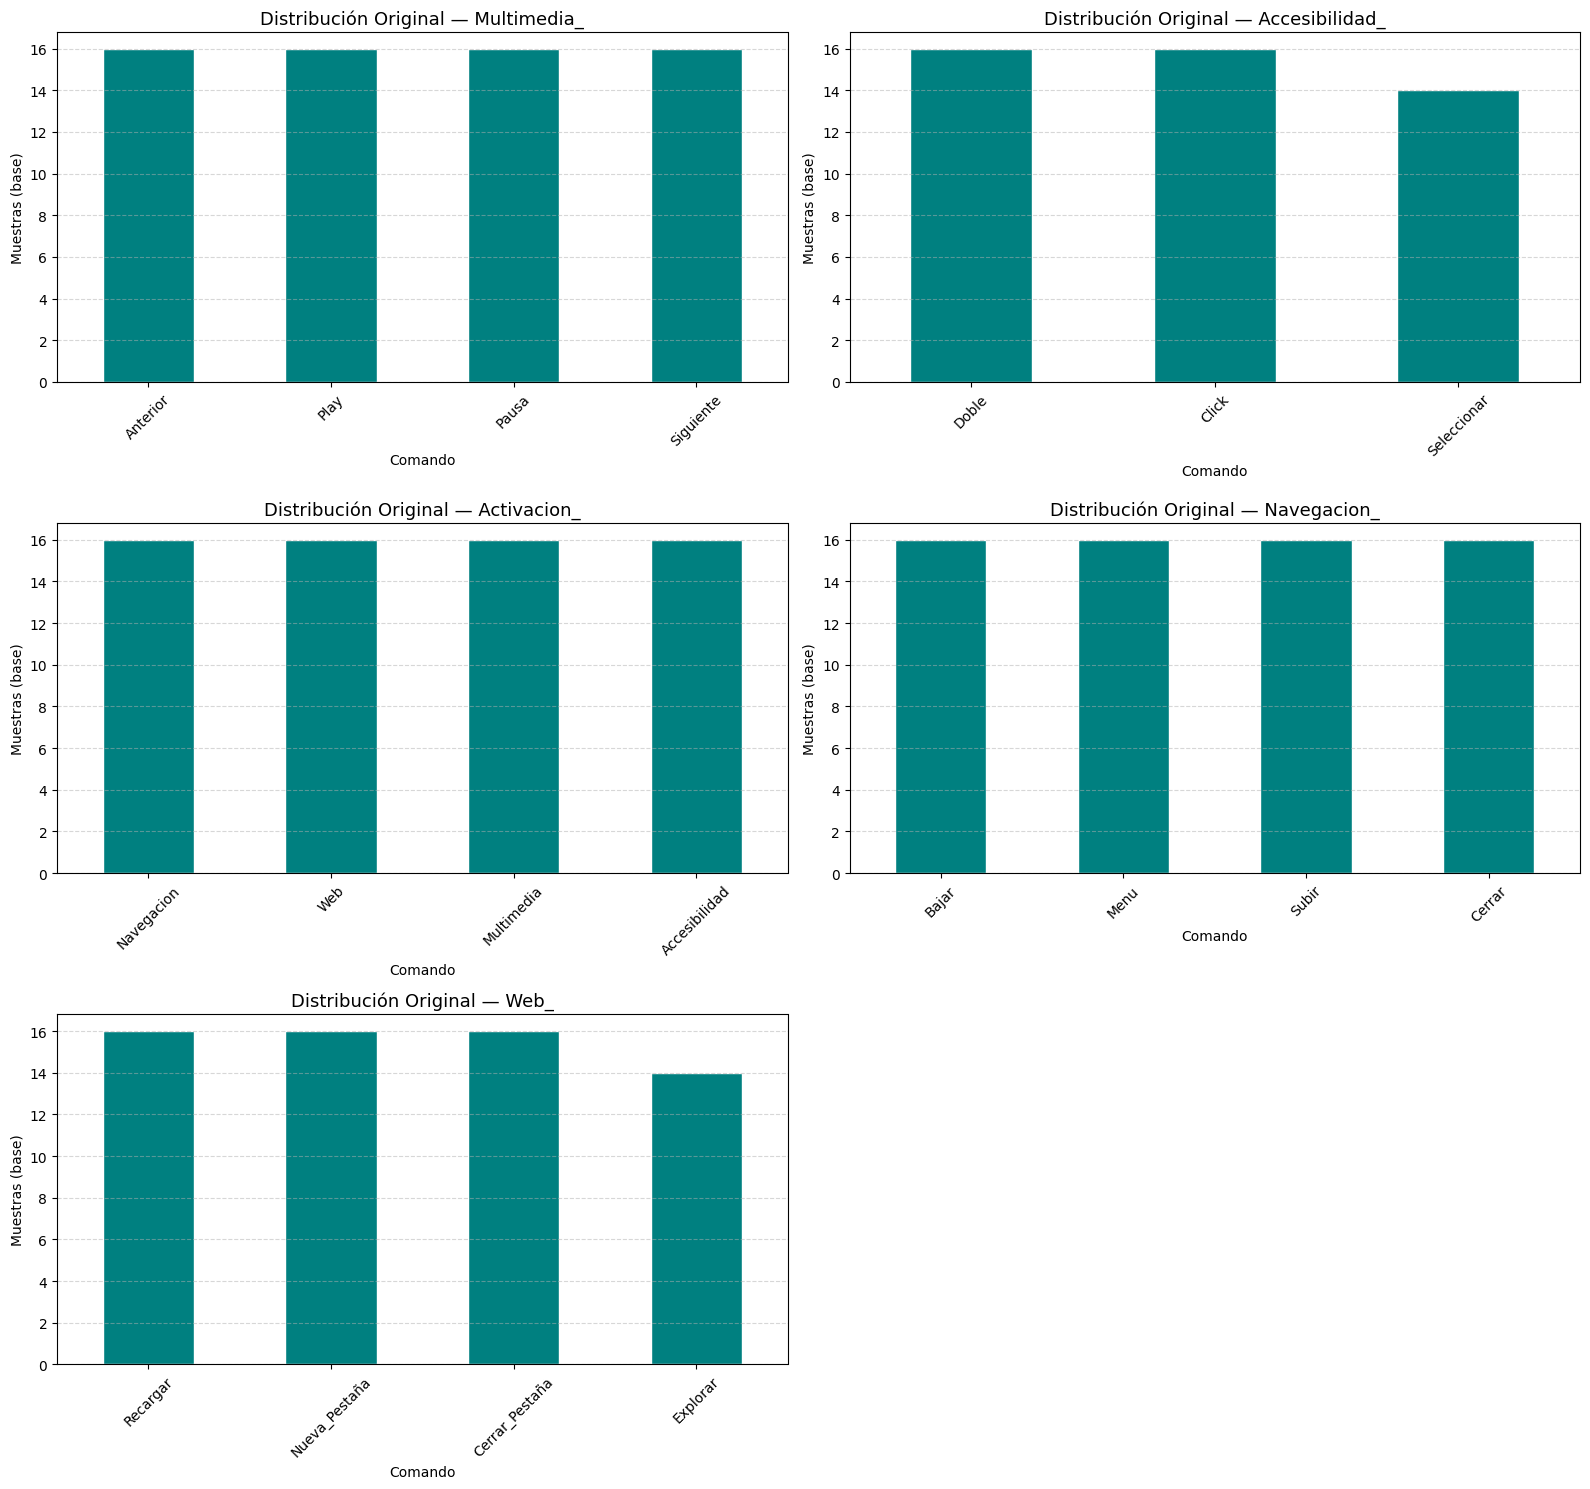

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.flatten()

modulos_nombres = df['module'].unique()

# Keep track of how many plots were actually made
num_plots_made = 0
for i, nombre_mod in enumerate(modulos_nombres):
    # Ensure we don't try to plot more than available axes
    if i >= len(axes):
        break
    df_mod_orig = df[df['module'] == nombre_mod]

    df_mod_orig['label'].value_counts().plot(kind='bar', ax=axes[i], color='teal', edgecolor='white')
    axes[i].set_title(f'Distribución Original — {nombre_mod}', fontsize=13)
    axes[i].set_xlabel('Comando')
    axes[i].set_ylabel('Muestras (base)')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)
    num_plots_made = i + 1

# Delete any unused axes
for j in range(num_plots_made, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 5. Train/Test Split (Preventing Leakage)
Dividimos los datos originales antes de aplicar aumentación o preprocesamiento.

In [ ]:
from sklearn.model_selection import train_test_split

# Diccionarios para guardar las rutas de archivos separadas
dic_rutas_split = {}
RANDOM_SEED = 42

for nombre_mod in df['module'].unique():
    df_mod = df[df['module'] == nombre_mod].reset_index(drop=True)

    train_df, test_df = train_test_split(
        df_mod,
        test_size=0.2,
        random_state=RANDOM_SEED,
        stratify=df_mod['label']
    )

    dic_rutas_split[nombre_mod] = {
        'train': train_df.reset_index(drop=True),
        'test': test_df.reset_index(drop=True)
    }
    print(f"Módulo '{nombre_mod}': Train={len(train_df)}, Test={len(test_df)}")

## 5. Preprocesamiento de Audio

**Mejora:** Se aumentó `top_db=25` para un trim más agresivo de silencios irrelevantes.

In [8]:
TARGET_SR = 16000
TARGET_LENGTH = 16000
TARGET_DUR = 1.0
PROCESSED_PATH = "/content/dataset_extraido/procesado"
RANDOM_SEED = 42

def preprocess_audio(file_path):
    """Carga, normaliza, resamplea y ajusta duración de un audio."""
    audio, sr = librosa.load(file_path, sr=TARGET_SR)

    # Trim más agresivo (top_db=25 en vez de 20)
    audio, _ = librosa.effects.trim(audio, top_db=25)

    # Normalización
    if np.max(np.abs(audio)) > 0:
        audio = audio / np.max(np.abs(audio))

    # Resample
    audio = librosa.resample(audio, orig_sr=sr, target_sr=TARGET_SR)

    # Ajuste de duración: crop centrado o padding
    current_length = len(audio)
    start = max(0, (current_length - TARGET_LENGTH) // 2)
    end = start + min(current_length, TARGET_LENGTH)
    audio = audio[start:end]

    pad_total = max(0, TARGET_LENGTH - len(audio))
    pad_before = pad_total // 2
    pad_after = pad_total - pad_before
    audio = np.pad(audio, (pad_before, pad_after), mode='constant')

    return audio

print("Procesando archivos de audio...")
for module in os.listdir(DATASET_PATH):
    module_path = os.path.join(DATASET_PATH, module)
    if os.path.isdir(module_path):
        for label in os.listdir(module_path):
            label_path = os.path.join(module_path, label)
            if os.path.isdir(label_path):
                output_label_path = os.path.join(PROCESSED_PATH, module, label)
                os.makedirs(output_label_path, exist_ok=True)
                for file in os.listdir(label_path):
                    if file.endswith(".wav"):
                        input_path = os.path.join(label_path, file)
                        output_path = os.path.join(output_label_path, file)
                        processed_audio = preprocess_audio(input_path)
                        sf.write(output_path, processed_audio, TARGET_SR)

print(f"Archivos procesados guardados en {PROCESSED_PATH}")

Procesando archivos de audio...
Archivos procesados guardados en /content/dataset_extraido/procesado


## 6. Funciones de Aumentación de Datos

**Mejora:** Se agregaron variantes adicionales (pitch down, time stretch up/down, volumen bajo/alto) → 9 variantes por audio en lugar de 3.

In [9]:
def add_noise(audio, noise_factor=0.005):
    noise = np.random.randn(len(audio))
    return audio + noise_factor * noise

def pitch_shift(audio, sr, n_steps=2):
    return librosa.effects.pitch_shift(audio, sr=sr, n_steps=n_steps)

def time_stretch(audio, rate=1.1):
    augmented = librosa.effects.time_stretch(audio, rate=rate)
    if np.max(np.abs(augmented)) > 0:
        augmented = augmented / np.max(np.abs(augmented))
    return augmented

def volume_change(audio, factor=1.2):
    augmented = audio * factor
    if np.max(np.abs(augmented)) > 0:
        augmented = augmented / np.max(np.abs(augmented))
    return augmented

def fix_audio_length(audio, target_length=TARGET_LENGTH):
    return librosa.util.fix_length(audio, size=target_length)

def augment_audio_extended(audio, sr):
    """
    Genera 9 variantes de un audio:
    1. Original
    2. Ruido suave
    3. Ruido moderado
    4. Pitch +2 semitonos
    5. Pitch -2 semitonos
    6. Time stretch x0.9 (más lento)
    7. Time stretch x1.1 (más rápido)
    8. Volumen bajo (0.7x)
    9. Volumen alto (1.3x)
    """
    variants = [
        audio,
        add_noise(audio, noise_factor=0.003),
        add_noise(audio, noise_factor=0.008),
        pitch_shift(audio, sr, n_steps=2),
        pitch_shift(audio, sr, n_steps=-2),
        fix_audio_length(time_stretch(audio, rate=0.9)),
        fix_audio_length(time_stretch(audio, rate=1.1)),
        volume_change(audio, factor=0.7),
        volume_change(audio, factor=1.3),
    ]
    return variants

print("Funciones de aumentación definidas (9 variantes por audio).")

Funciones de aumentación definidas (9 variantes por audio).


## 7. Extracción de Features — V3
**Mejoras respecto a V2:**
- 26 MFCCs (en vez de 13) + sus deltas
- Mel Spectrogram con 128 bandas (mayor resolución espectral)
- Zero Crossing Rate (distingue sonidos sonoros de sordos)
- Spectral Contrast (diferencia entre picos espectrales y valles)

In [10]:
def extract_features_v3(audio, sr):
    """
    Vector de features enriquecido:
    - 26 MFCCs (mean + std)
    - Delta MFCCs (mean)
    - 12 Chroma features
    - 128 Mel spectrogram bands (mean)
    - Zero Crossing Rate (mean + std)
    - 7 Spectral Contrast bands
    - Centroide espectral, RMS, Rolloff, Flatness, Bandwidth
    Total: ~253 features
    """
    features = []
    n_samples = len(audio)
    n_fft = min(n_samples, 1024)
    hop_length = n_fft // 4

    # --- MFCCs (26 coeficientes) ---
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=26,
                                  n_fft=n_fft, hop_length=hop_length)
    features.extend(np.mean(mfccs, axis=1))
    features.extend(np.std(mfccs, axis=1))

    # --- Delta MFCCs (captura dinámica temporal) ---
    delta_mfcc = librosa.feature.delta(mfccs)
    features.extend(np.mean(delta_mfcc, axis=1))

    # --- Chroma (12 semitonos) ---
    chroma = librosa.feature.chroma_stft(y=audio, sr=sr,
                                          n_fft=n_fft, hop_length=hop_length)
    features.extend(np.mean(chroma, axis=1))

    # --- Mel Spectrogram (128 bandas, media por banda) ---
    n_mels = min(128, n_fft // 2 + 1)
    mel = librosa.feature.melspectrogram(y=audio, sr=sr,
                                          n_fft=n_fft, hop_length=hop_length,
                                          n_mels=n_mels)
    mel_db = librosa.power_to_db(mel)
    features.extend(np.mean(mel_db, axis=1))

    # --- Zero Crossing Rate ---
    zcr = librosa.feature.zero_crossing_rate(audio, hop_length=hop_length)
    features.append(np.mean(zcr))
    features.append(np.std(zcr))

    # --- Spectral Contrast ---
    try:
        contrast = librosa.feature.spectral_contrast(y=audio, sr=sr,
                                                      n_fft=n_fft, hop_length=hop_length)
        features.extend(np.mean(contrast, axis=1))
    except Exception:
        features.extend([0.0] * 7)

    # --- Features espectrales adicionales ---
    centroid = librosa.feature.spectral_centroid(y=audio, sr=sr,
                                                  n_fft=n_fft, hop_length=hop_length)
    features.append(np.mean(centroid))
    features.append(np.std(centroid))

    rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr,
                                                n_fft=n_fft, hop_length=hop_length)
    features.append(np.mean(rolloff))
    features.append(np.std(rolloff))

    flatness = librosa.feature.spectral_flatness(y=audio, n_fft=n_fft,
                                                  hop_length=hop_length)
    features.append(np.mean(flatness))

    bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr,
                                                    n_fft=n_fft, hop_length=hop_length)
    features.append(np.mean(bandwidth))

    rms = librosa.feature.rms(y=audio, hop_length=hop_length)
    features.append(np.mean(rms))
    features.append(np.std(rms))
    features.append(np.max(rms))

    return np.array(features, dtype=np.float32)


def create_feature_names_v3(n_mels=128):
    names = []
    for i in range(1, 27): names.append(f'mfcc_{i}_mean')
    for i in range(1, 27): names.append(f'mfcc_{i}_std')
    for i in range(1, 27): names.append(f'delta_mfcc_{i}_mean')
    for i in range(1, 13): names.append(f'chroma_{i}')
    for i in range(1, n_mels + 1): names.append(f'mel_{i}')
    names.extend(['zcr_mean', 'zcr_std'])
    for i in range(1, 8): names.append(f'contrast_{i}')
    names.extend(['centroid_mean', 'centroid_std',
                  'rolloff_mean', 'rolloff_std',
                  'flatness_mean', 'bandwidth_mean',
                  'rms_mean', 'rms_std', 'rms_max'])
    return names

feature_columns_v3 = create_feature_names_v3(n_mels=128)
print(f"Tamaño del vector de features V3: {len(feature_columns_v3)} features")

Tamaño del vector de features V3: 236 features


## 8. Extracción de Features + Aumentación sobre el Dataset Completo

In [11]:
import pandas as pd

def procesar_split(nombre_mod, df_split, aumentar=False):
    """Extrae features para un conjunto (train o test) específico."""
    X_list, y_list = [], []

    for _, row in df_split.iterrows():
        try:
            audio, sr = librosa.load(row['path'], sr=TARGET_SR)
            if aumentar:
                # Solo aumentamos en entrenamiento
                variantes = augment_audio_extended(audio, sr)
            else:
                variantes = [audio]

            for v in variantes:
                feat = extract_features_v3(v, TARGET_SR)
                X_list.append(feat)
                y_list.append(row['label'])
        except Exception:
            continue

    # CORRECCIÓN: Estas líneas deben estar dentro de la función (indentadas)
    X_df = pd.DataFrame(X_list, columns=feature_columns_v3)
    y_ser = pd.Series(y_list, name='label')
    return X_df, y_ser

dic_train_test = {}

# Ahora ejecutamos el procesamiento para cada módulo
for nombre_mod, splits in dic_rutas_split.items():
    print(f"\nProcesando {nombre_mod}...")
    X_train, y_train = procesar_split(nombre_mod, splits['train'], aumentar=True)
    X_test, y_test = procesar_split(nombre_mod, splits['test'], aumentar=False)

    dic_train_test[nombre_mod] = {
        'X_train': X_train, 'y_train': y_train,
        'X_test': X_test, 'y_test': y_test
    }
    print(f"  Finalizado: X_train shape {X_train.shape}, X_test shape {X_test.shape}")


Procesando Multimedia_...
  Finalizado: X_train shape (459, 236), X_test shape (13, 236)

Procesando Accesibilidad_...
  Finalizado: X_train shape (324, 236), X_test shape (10, 236)

Procesando Activacion_...
  Finalizado: X_train shape (459, 236), X_test shape (13, 236)

Procesando Navegacion_...
  Finalizado: X_train shape (459, 236), X_test shape (13, 236)

Procesando Web_...
  Finalizado: X_train shape (441, 236), X_test shape (13, 236)


In [12]:
# DataFrame de referencia con paths
df_ref = pd.DataFrame(data)
df_ref.index = range(len(df_ref))

# Módulos disponibles
modulos_nombres = df_ref['module'].unique()
modulos_raw = {m: df_ref[df_ref['module'] == m].reset_index(drop=True)
               for m in modulos_nombres}

print("Módulos encontrados:", list(modulos_raw.keys()))


def extraer_y_aumentar_modulo(nombre_mod, df_mod):
    """
    Para cada audio del módulo genera 9 variantes aumentadas
    y extrae features V3 de cada una.
    """
    print(f"Procesando módulo '{nombre_mod}' ({len(df_mod)} audios originales)...")
    X_list, y_list = [], []

    for _, row in df_mod.iterrows():
        try:
            audio, sr = librosa.load(row['path'], sr=TARGET_SR)
            variantes = augment_audio_extended(audio, sr)
            for v in variantes:
                feat = extract_features_v3(v, TARGET_SR)
                if len(feat) == len(feature_columns_v3):
                    X_list.append(feat)
                    y_list.append(row['label'])
        except Exception as e:
            continue

    X_df = pd.DataFrame(X_list, columns=feature_columns_v3)
    y_ser = pd.Series(y_list, name='label')
    print(f"{len(X_df)} muestras generadas.")
    return X_df, y_ser


print("\nExtrayendo features con aumentación extendida...")
modulos_X = {}
modulos_y = {}

for nombre_mod, df_mod in modulos_raw.items():
    X, y = extraer_y_aumentar_modulo(nombre_mod, df_mod)
    modulos_X[nombre_mod] = X
    modulos_y[nombre_mod] = y

print("\nExtracción completa.")

Módulos encontrados: ['Multimedia_', 'Accesibilidad_', 'Activacion_', 'Navegacion_', 'Web_']

Extrayendo features con aumentación extendida...
Procesando módulo 'Multimedia_' (64 audios originales)...
576 muestras generadas.
Procesando módulo 'Accesibilidad_' (46 audios originales)...
414 muestras generadas.
Procesando módulo 'Activacion_' (64 audios originales)...
576 muestras generadas.
Procesando módulo 'Navegacion_' (64 audios originales)...
576 muestras generadas.
Procesando módulo 'Web_' (62 audios originales)...
558 muestras generadas.

Extracción completa.


## 9. Visualizaciones Exploratorias

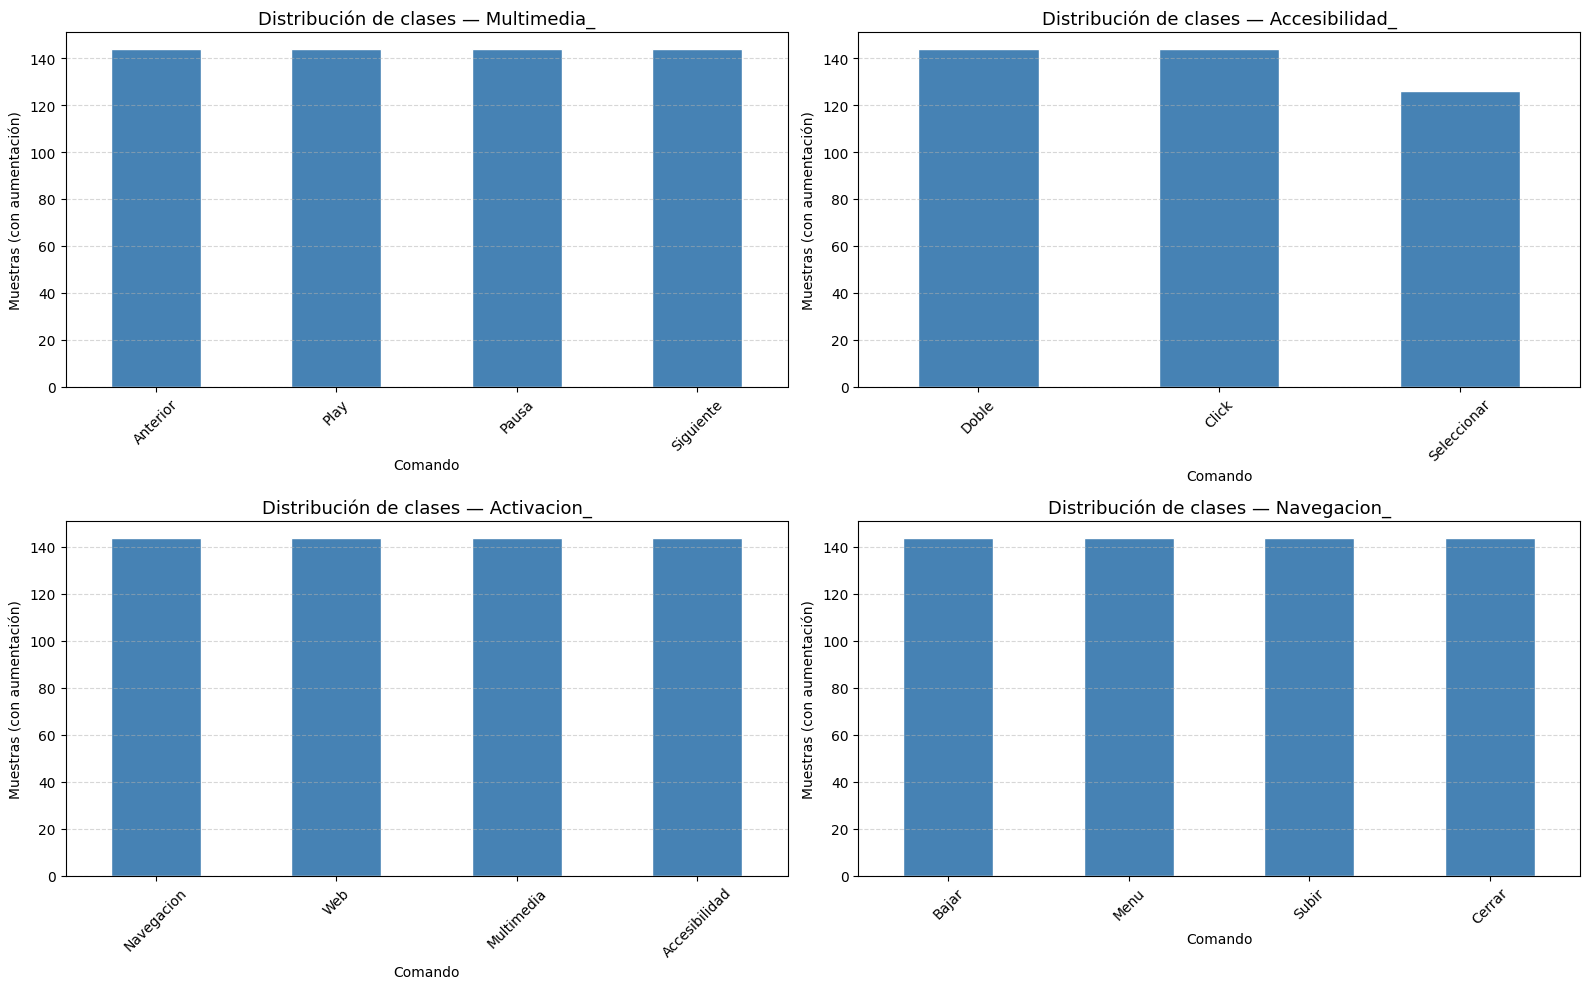

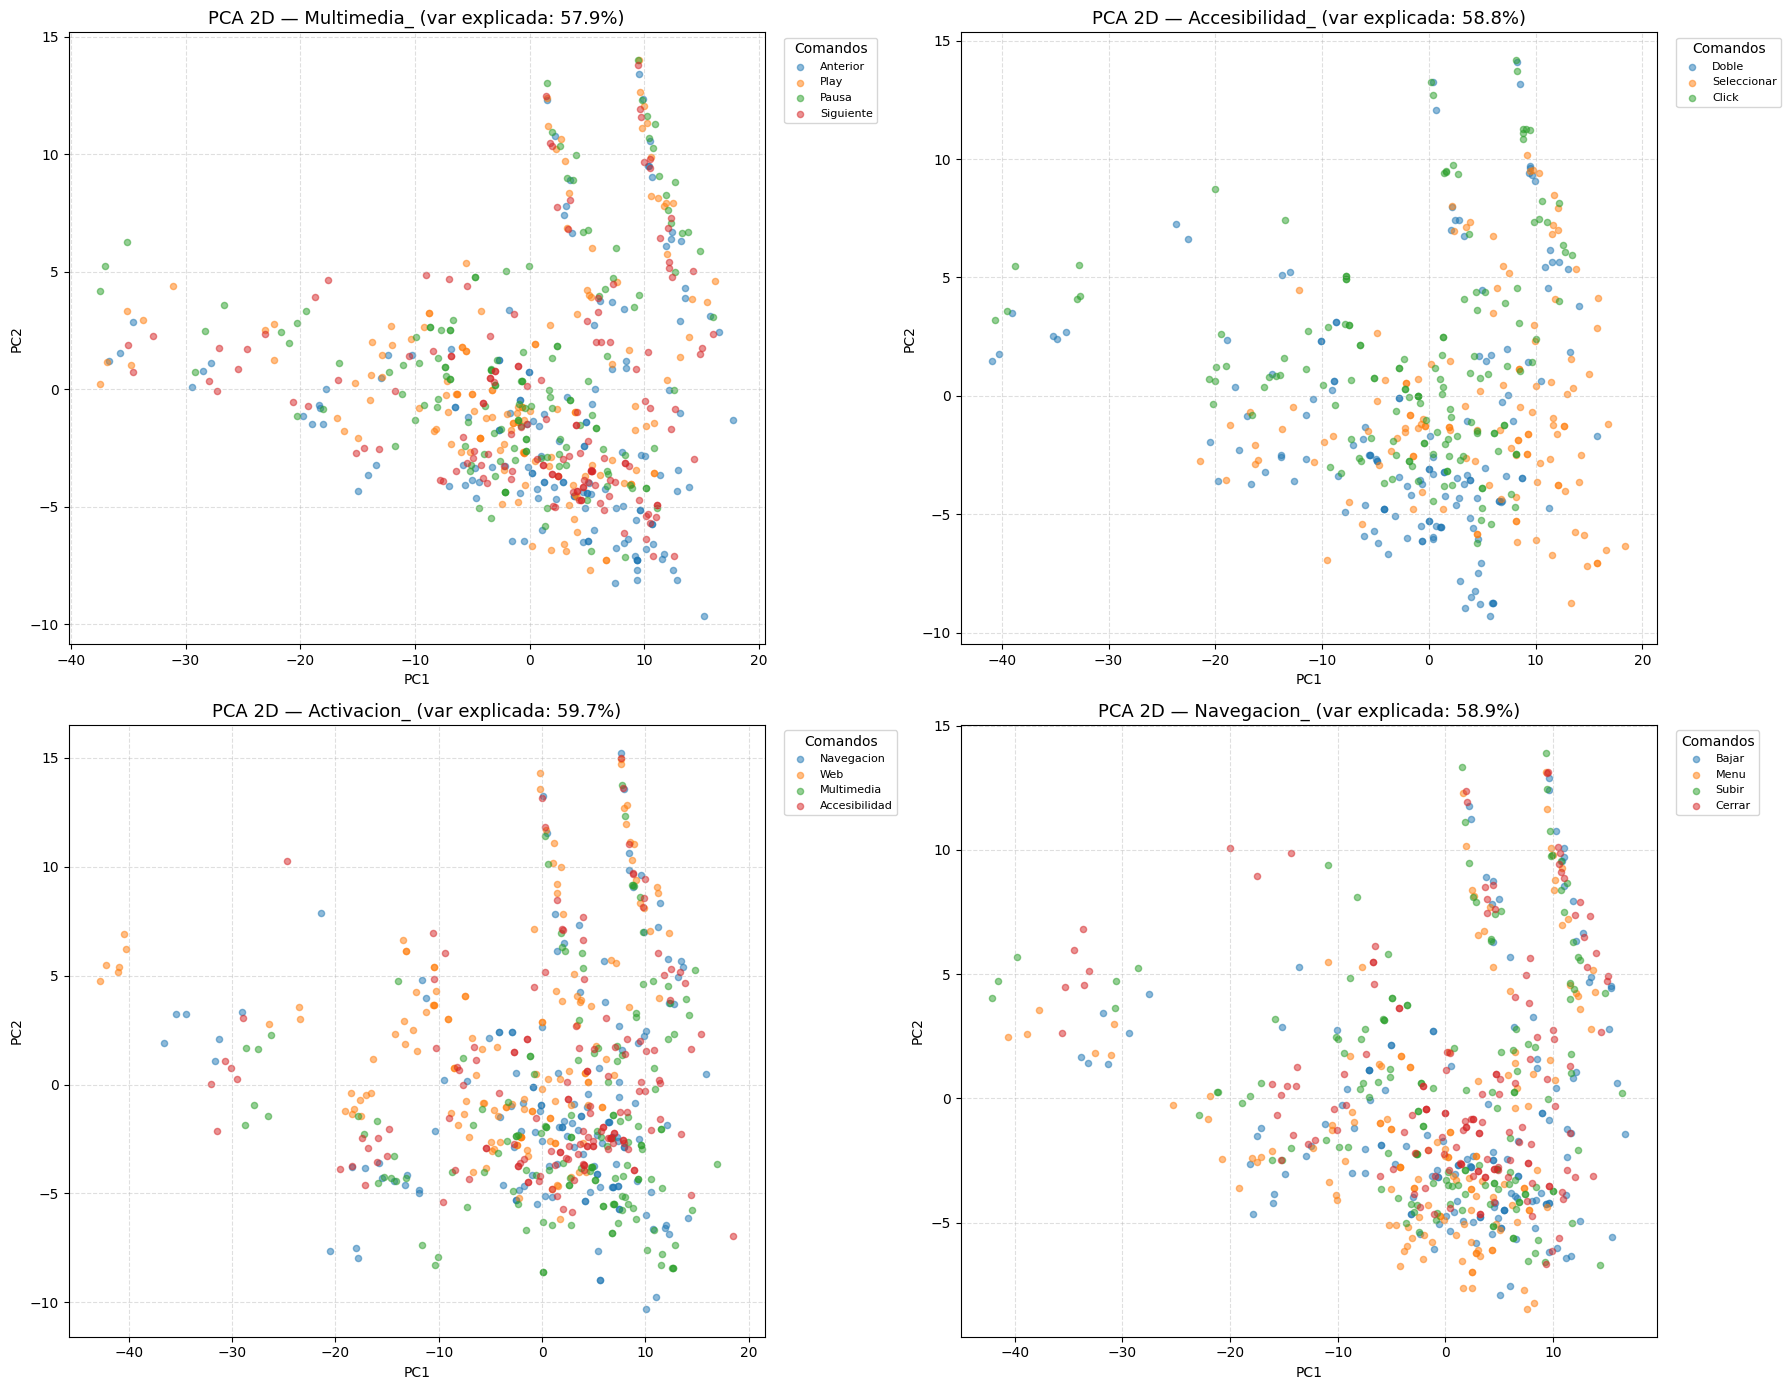

In [13]:
# Distribución de muestras por clase y módulo
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (nombre_mod, y) in enumerate(modulos_y.items()):
    if i >= 4: break
    y.value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribución de clases — {nombre_mod}', fontsize=13)
    axes[i].set_xlabel('Comando')
    axes[i].set_ylabel('Muestras (con aumentación)')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

for j in range(i + 1, 4):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# PCA 2D por módulo
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (nombre_mod, X) in enumerate(modulos_X.items()):
    if i >= 4: break
    ax = axes[i]
    y = modulos_y[nombre_mod]

    scaler_pca = StandardScaler()
    X_scaled = scaler_pca.fit_transform(X)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    for clase in y.unique():
        idx = y == clase
        ax.scatter(X_pca[idx, 0], X_pca[idx, 1], label=clase, alpha=0.5, s=20)

    ax.set_title(f'PCA 2D — {nombre_mod} (var explicada: {pca.explained_variance_ratio_.sum():.1%})',
                 fontsize=13)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(linestyle='--', alpha=0.4)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Comandos', fontsize=8)

for j in range(i + 1, 4):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 10. Train/Test Split por Módulo

In [14]:
dic_train_test = {}

for nombre_mod in modulos_X.keys():
    X_mod = modulos_X[nombre_mod]
    y_mod = modulos_y[nombre_mod]

    X_train, X_test, y_train, y_test = train_test_split(
        X_mod, y_mod,
        test_size=0.2,
        random_state=RANDOM_SEED,
        stratify=y_mod
    )

    dic_train_test[nombre_mod] = {
        'X_train': X_train.reset_index(drop=True),
        'X_test':  X_test.reset_index(drop=True),
        'y_train': y_train.reset_index(drop=True),
        'y_test':  y_test.reset_index(drop=True),
    }
    print(f"Módulo '{nombre_mod}': train={len(X_train)}, test={len(X_test)}")

print("\n plits realizados para todos los módulos.")

Módulo 'Multimedia_': train=460, test=116
Módulo 'Accesibilidad_': train=331, test=83
Módulo 'Activacion_': train=460, test=116
Módulo 'Navegacion_': train=460, test=116
Módulo 'Web_': train=446, test=112

 plits realizados para todos los módulos.


## 11. Selección de Features con Random Forest

Se seleccionan las 60 features más importantes por módulo (en vez de 30) dado el mayor vector disponible.

Multimedia_: 60 features seleccionadas
Accesibilidad_: 60 features seleccionadas
Activacion_: 60 features seleccionadas
Navegacion_: 60 features seleccionadas
Web_: 60 features seleccionadas


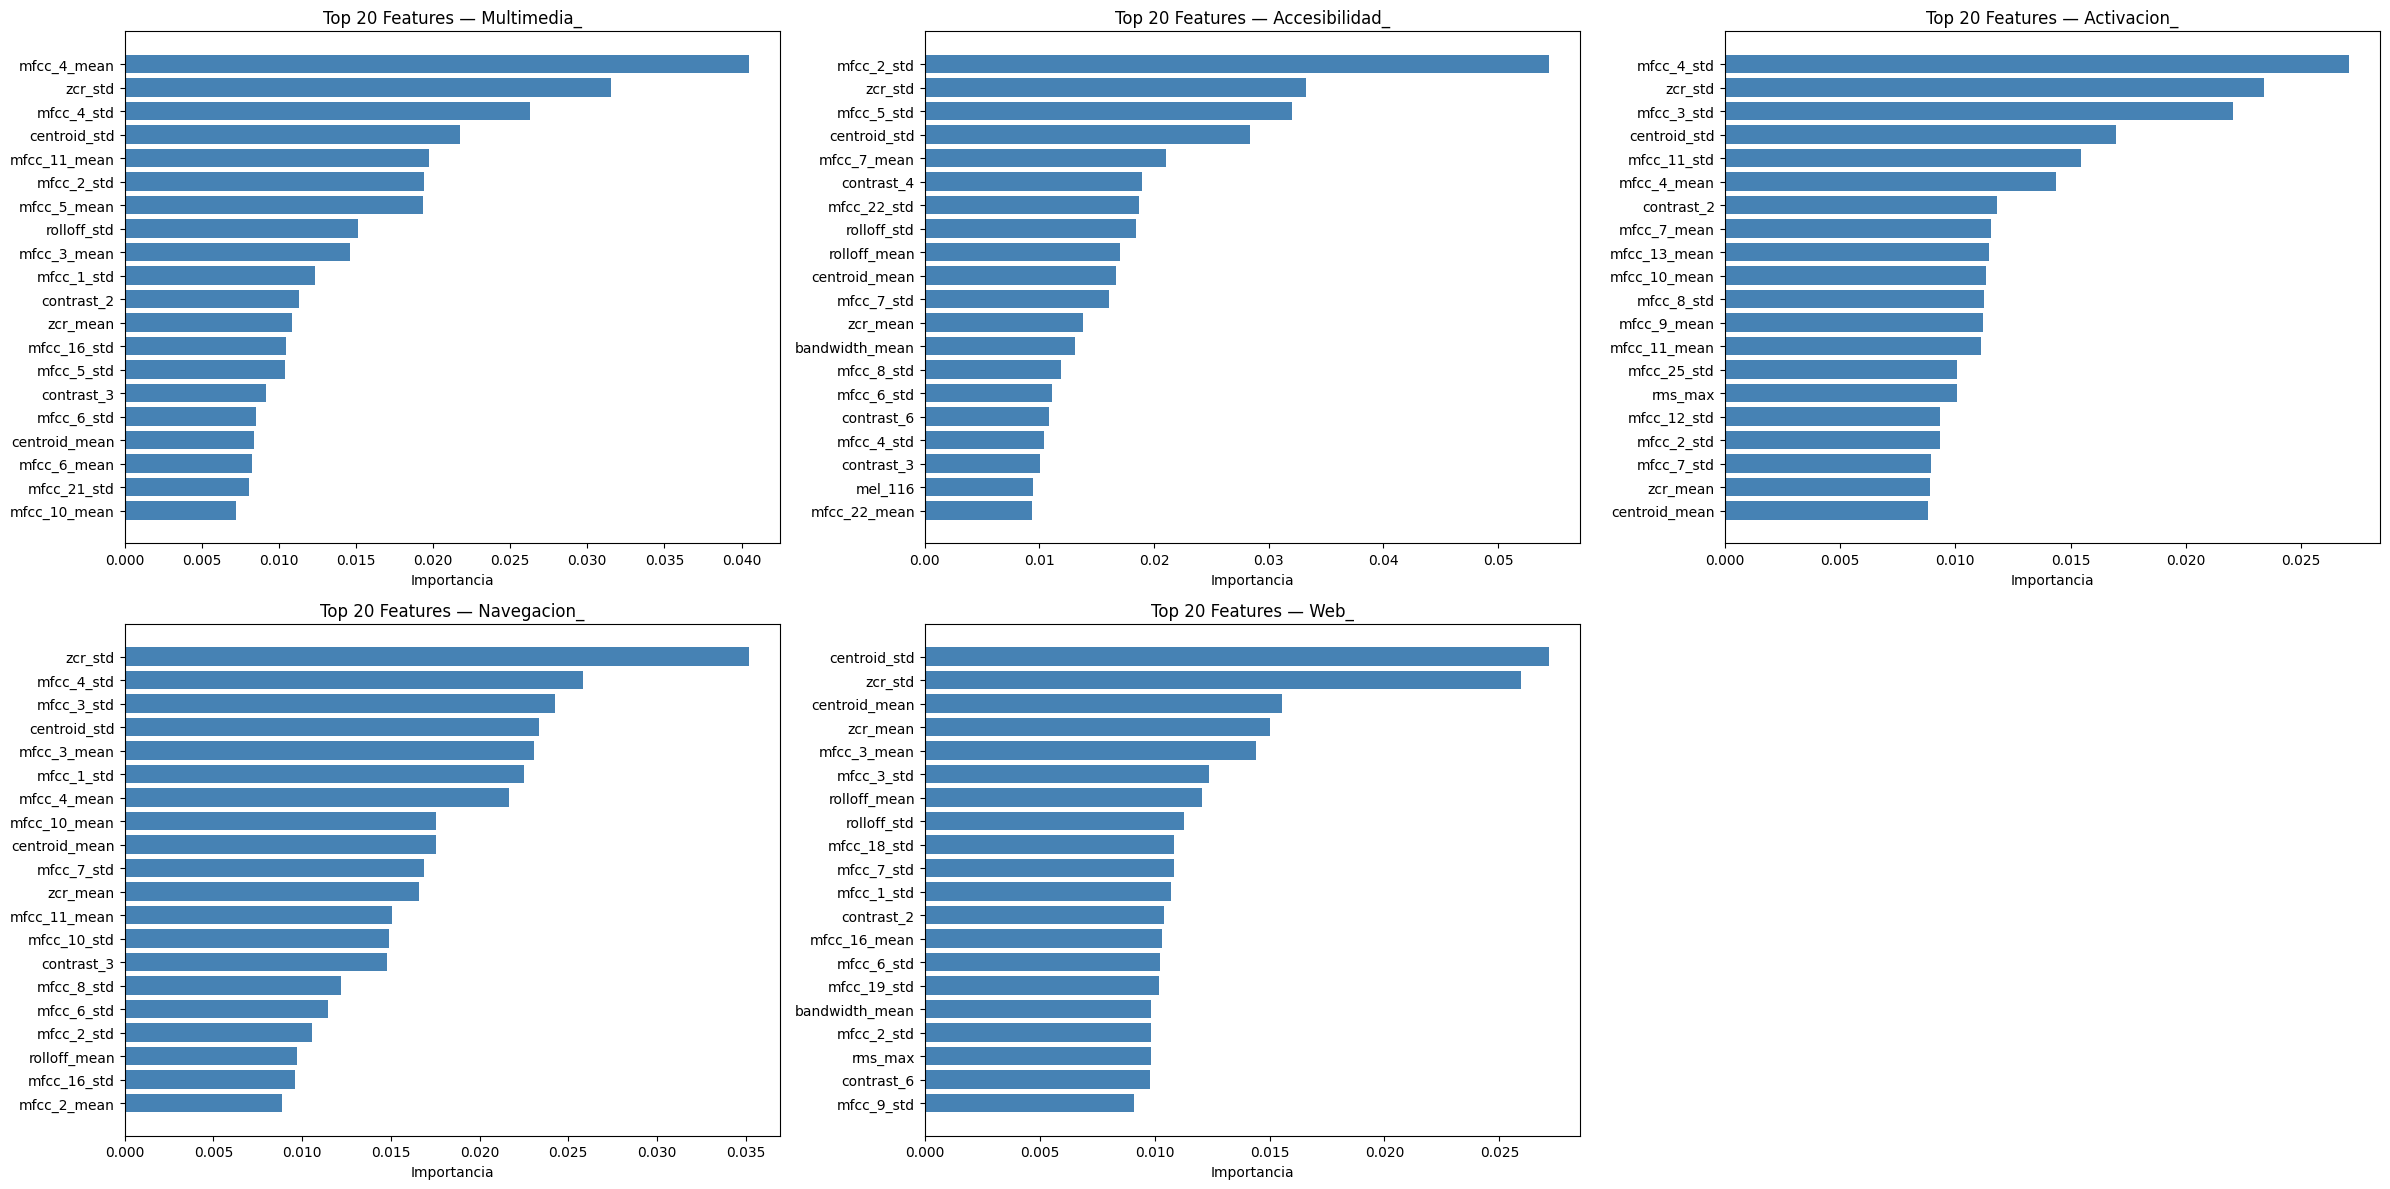

In [23]:
TOP_N_FEATURES = 60
mejores_features_por_modulo = {}

fig, axes = plt.subplots(2, 3, figsize=(24, 12)) # Changed to 2 rows, 3 columns to accommodate more modules
axes = axes.flatten()

num_modules_to_process = len(modulos_X.keys())

for i, (nombre_mod, X) in enumerate(modulos_X.items()):
    # Removed the `if i >= 4: break` condition to ensure all modules are processed
    y = modulos_y[nombre_mod]

    rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
    rf.fit(X, y)

    importancias = pd.Series(rf.feature_importances_, index=X.columns)
    top_features = importancias.sort_values(ascending=False).head(TOP_N_FEATURES).index.tolist()
    mejores_features_por_modulo[nombre_mod] = top_features

    # Plot top 20 para visualización
    top20 = importancias.sort_values(ascending=False).head(20)
    axes[i].barh(top20.index[::-1], top20.values[::-1], color='steelblue')
    axes[i].set_title(f'Top 20 Features — {nombre_mod}', fontsize=12)
    axes[i].set_xlabel('Importancia')

    print(f"{nombre_mod}: {len(top_features)} features seleccionadas")

# Delete any unused axes if there are fewer modules than subplots
for j in range(num_modules_to_process, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 12. Entrenamiento — Pipeline C

**Mejoras vs Pipeline B:**
- Clasificador XGBoost (si disponible)
- Features V3 enriquecidas
- Top 60 features por módulo
- SMOTE para balanceo de clases


=== Entrenando Módulo: Multimedia_ (Pipeline C - Balanceado) ===
  Balanceo: 460 → 460 muestras
Accuracy: 0.8362
              precision    recall  f1-score   support

    Anterior       0.79      0.79      0.79        29
       Pausa       0.93      0.97      0.95        29
        Play       0.90      0.66      0.76        29
   Siguiente       0.75      0.93      0.83        29

    accuracy                           0.84       116
   macro avg       0.85      0.84      0.83       116
weighted avg       0.85      0.84      0.83       116



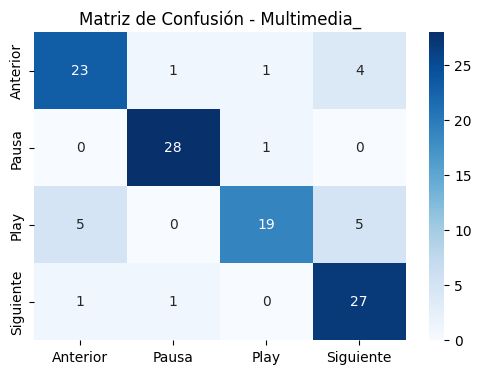


=== Entrenando Módulo: Accesibilidad_ (Pipeline C - Balanceado) ===
  Balanceo: 331 → 345 muestras
Accuracy: 0.9518
              precision    recall  f1-score   support

       Click       0.96      0.93      0.95        29
       Doble       0.93      0.93      0.93        29
 Seleccionar       0.96      1.00      0.98        25

    accuracy                           0.95        83
   macro avg       0.95      0.95      0.95        83
weighted avg       0.95      0.95      0.95        83



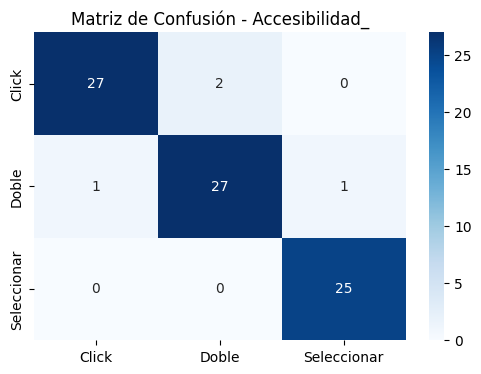


=== Entrenando Módulo: Activacion_ (Pipeline C - Balanceado) ===
  Balanceo: 460 → 460 muestras
Accuracy: 0.8448
               precision    recall  f1-score   support

Accesibilidad       0.85      0.79      0.82        29
   Multimedia       0.84      0.90      0.87        29
   Navegacion       0.79      0.79      0.79        29
          Web       0.90      0.90      0.90        29

     accuracy                           0.84       116
    macro avg       0.85      0.84      0.84       116
 weighted avg       0.85      0.84      0.84       116



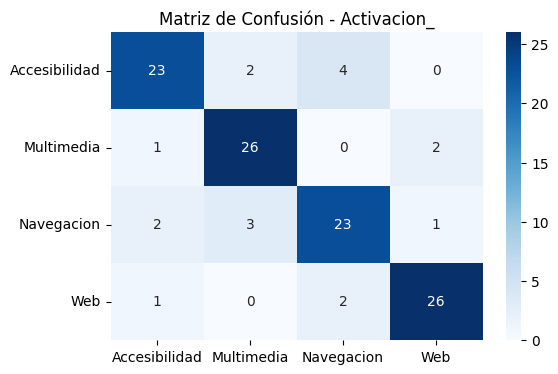


=== Entrenando Módulo: Navegacion_ (Pipeline C - Balanceado) ===
  Balanceo: 460 → 460 muestras
Accuracy: 0.8621
              precision    recall  f1-score   support

       Bajar       0.90      0.93      0.92        29
      Cerrar       0.89      0.83      0.86        29
        Menu       0.88      0.79      0.84        29
       Subir       0.79      0.90      0.84        29

    accuracy                           0.86       116
   macro avg       0.87      0.86      0.86       116
weighted avg       0.87      0.86      0.86       116



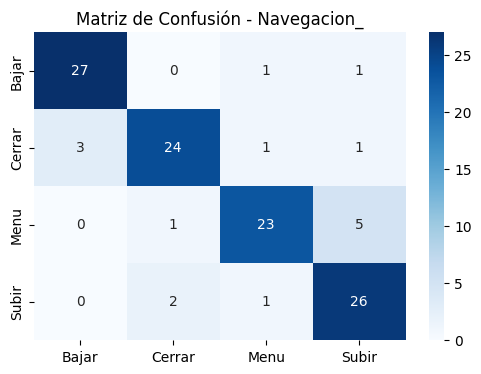


=== Entrenando Módulo: Web_ (Pipeline C - Balanceado) ===
  Balanceo: 446 → 460 muestras
Accuracy: 0.8839
                precision    recall  f1-score   support

Cerrar_Pestaña       0.85      0.79      0.82        29
      Explorar       0.85      0.92      0.88        25
 Nueva_Pestaña       0.93      0.86      0.89        29
      Recargar       0.90      0.97      0.93        29

      accuracy                           0.88       112
     macro avg       0.88      0.89      0.88       112
  weighted avg       0.88      0.88      0.88       112



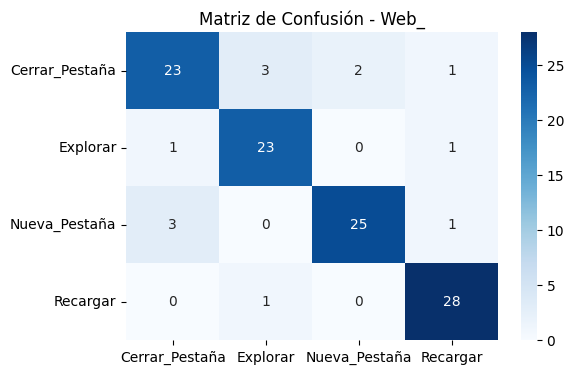

In [21]:
modelos_pipeline_c = {}


for nombre_mod in dic_train_test.keys():
    print(f"\n=== Entrenando Módulo: {nombre_mod} (Pipeline C - Balanceado) ===")

    features = mejores_features_por_modulo[nombre_mod]

    X_train = dic_train_test[nombre_mod]['X_train'][features]
    y_train = dic_train_test[nombre_mod]['y_train']
    X_test  = dic_train_test[nombre_mod]['X_test'][features]
    y_test  = dic_train_test[nombre_mod]['y_test']

    # Escalado
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # Balanceo con SMOTE (estándar)
    smote = SMOTE(random_state=RANDOM_SEED)
    X_res, y_res = smote.fit_resample(X_train_scaled, y_train)

    print(f"  Balanceo: {len(X_train_scaled)} → {len(X_res)} muestras")

    # Clasificador
    le = LabelEncoder()
    y_res_enc = le.fit_transform(y_res)
    y_test_enc = le.transform(y_test)

    clf = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )

    clf.fit(X_res, y_res_enc)
    y_pred_enc = clf.predict(X_test_scaled)
    y_pred = le.inverse_transform(y_pred_enc)

    modelos_pipeline_c[nombre_mod] = {
        'model': clf,
        'scaler': scaler,
        'features': features,
        'label_encoder': le,
        'tipo': 'xgboost'}

    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Matriz de confusión
    plt.figure(figsize=(6, 4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Matriz de Confusión - {nombre_mod}')
    plt.show()

In [26]:
print(modelos_pipeline_c['Multimedia_']['label_encoder'].classes_)
print(modelos_pipeline_c['Web_']['label_encoder'].classes_)
print(modelos_pipeline_c['Navegacion_']['label_encoder'].classes_)
print(modelos_pipeline_c['Accesibilidad_']['label_encoder'].classes_)
print(modelos_pipeline_c['Activacion_']['label_encoder'].classes_)

['Anterior' 'Pausa' 'Play' 'Siguiente']
['Cerrar_Pestaña' 'Explorar' 'Nueva_Pestaña' 'Recargar']
['Bajar' 'Cerrar' 'Menu' 'Subir']
['Click' 'Doble' 'Seleccionar']
['Accesibilidad' 'Multimedia' 'Navegacion' 'Web']


## 13. Validación Cruzada (5-Fold) — Pipeline C

In [27]:
print("=== VALIDACIÓN CRUZADA 5-FOLD — PIPELINE C ===\n")

for nombre_mod in modulos_X.keys():
    features = mejores_features_por_modulo[nombre_mod]
    X_all = modulos_X[nombre_mod][features]
    y_all = modulos_y[nombre_mod]

    scaler_cv = StandardScaler()
    X_scaled_cv = scaler_cv.fit_transform(X_all)

    le_cv = LabelEncoder()
    y_enc_cv = le_cv.fit_transform(y_all)

    clf_cv = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                            eval_metric='mlogloss',
                            random_state=RANDOM_SEED, n_jobs=-1)

    cv_results = cross_validate(clf_cv, X_scaled_cv, y_enc_cv, cv=5, return_train_score=True)

    train_mean = cv_results['train_score'].mean()
    test_mean  = cv_results['test_score'].mean()
    gap = train_mean - test_mean

    print(f"Módulo: {nombre_mod}")
    print(f"  Accuracy train promedio : {train_mean:.4f}")
    print(f"  Accuracy val  promedio  : {test_mean:.4f}")
    print(f"  Gap (overfitting)       : {gap:.4f}")
    if gap > 0.15:
        print(" Posible overfitting (gap > 15%)")
    else:
        print(" Modelo robusto")
    print("-" * 45)

=== VALIDACIÓN CRUZADA 5-FOLD — PIPELINE C ===

Módulo: Multimedia_
  Accuracy train promedio : 1.0000
  Accuracy val  promedio  : 0.6129
  Gap (overfitting)       : 0.3871
 Posible overfitting (gap > 15%)
---------------------------------------------
Módulo: Accesibilidad_
  Accuracy train promedio : 1.0000
  Accuracy val  promedio  : 0.8309
  Gap (overfitting)       : 0.1691
 Posible overfitting (gap > 15%)
---------------------------------------------
Módulo: Activacion_
  Accuracy train promedio : 1.0000
  Accuracy val  promedio  : 0.6078
  Gap (overfitting)       : 0.3922
 Posible overfitting (gap > 15%)
---------------------------------------------
Módulo: Navegacion_
  Accuracy train promedio : 1.0000
  Accuracy val  promedio  : 0.6683
  Gap (overfitting)       : 0.3317
 Posible overfitting (gap > 15%)
---------------------------------------------
Módulo: Web_
  Accuracy train promedio : 1.0000
  Accuracy val  promedio  : 0.5073
  Gap (overfitting)       : 0.4927
 Posible overfi

# EXPORTAR MODELOS

In [29]:
import joblib
import os
import shutil
from google.colab import files

# Create a directory to store the models
output_dir = "modelos_pipeline_c"
os.makedirs(output_dir, exist_ok=True)
print(f"Created directory: '{output_dir}/'")

# Save each model in modelos_pipeline_c
print("Saving individual models...")
for nombre_mod, pipeline_info in modelos_pipeline_c.items():
    model_filename = os.path.join(output_dir, f"{nombre_mod}_pipeline.pkl")
    joblib.dump(
        pipeline_info, # Save the entire pipeline info for the module
        model_filename
    )
    print(f"  Saved: '{model_filename}'")

print(f"All models from 'modelos_pipeline_c' saved to '{output_dir}/'")

# Create a zip archive of the saved models
print("Creating zip archive...")
zip_filename = f"{output_dir}.zip"
shutil.make_archive(
    output_dir,
    "zip",
    output_dir
)
print(f"Models zipped to '{zip_filename}'")

# Provide a download link
print("Initiating download...")
files.download(zip_filename)
print("Download initiated.")

All models from 'modelos_pipeline_c' saved to 'modelos_pipeline_c/'
Models zipped to 'modelos_pipeline_c.zip'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download initiated.


## 15. Probar con Audio

Esta función carga **cualquier archivo de audio** (`.wav`, `.mp3`, `.ogg`, `.flac`)

Soporta dos modos:
- **Desde archivo en disco / subido a Colab**
- **Desde array numpy** (si ya tenés el audio cargado)

In [ ]:
def predict_from_raw_audio(audio_input, module_name, sr_input=None, show_plot=True):
    """
    Predice el comando de voz a partir de un archivo de audio raw.

    Args:
        audio_input : str  → ruta al archivo (.wav, .mp3, .ogg, .flac)
                      np.ndarray → array de audio ya cargado (requiere sr_input)
        module_name : str  → 'Web_', 'Navegacion_', 'Multimedia_', 'Accesibilidad_'
                             (o cualquier clave de modelos_pipeline_c)
        sr_input    : int  → sample rate si audio_input es array (default: TARGET_SR)
        show_plot   : bool → muestra waveform y espectrograma del audio

    Returns:
        prediction  : str  → comando predicho
        probs_sorted: list → [(clase, probabilidad%), ...] ordenado desc
    """
    TARGET_SR_LOCAL = 16000
    TARGET_LEN_LOCAL = 16000

    # ----- 1. Carga -----
    if isinstance(audio_input, str):
        if not os.path.exists(audio_input):
            print(f"Archivo no encontrado: {audio_input}")
            return None, None
        audio_raw, sr_raw = librosa.load(audio_input, sr=TARGET_SR_LOCAL)
        print(f"Archivo cargado: {os.path.basename(audio_input)}")
    elif isinstance(audio_input, np.ndarray):
        sr_raw = sr_input if sr_input else TARGET_SR_LOCAL
        audio_raw = librosa.resample(audio_input, orig_sr=sr_raw, target_sr=TARGET_SR_LOCAL)
        sr_raw = TARGET_SR_LOCAL
        print("Array de audio recibido.")
    else:
        print("audio_input debe ser una ruta (str) o array numpy.")
        return None, None

    print(f"   Duración original: {len(audio_raw) / sr_raw:.2f}s | SR: {sr_raw} Hz")

    # ----- 2. Preprocesamiento (igual que entrenamiento) -----
    audio, _ = librosa.effects.trim(audio_raw, top_db=25)
    if np.max(np.abs(audio)) > 0:
        audio = audio / np.max(np.abs(audio))
    audio = librosa.util.fix_length(audio, size=TARGET_LEN_LOCAL)

    # ----- 3. Visualización -----
    if show_plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 3))

        axes[0].plot(np.linspace(0, 1, len(audio)), audio, color='steelblue', linewidth=0.5)
        axes[0].set_title('Waveform (preprocesado)')
        axes[0].set_xlabel('Tiempo (s)')
        axes[0].set_ylabel('Amplitud')
        axes[0].grid(linestyle='--', alpha=0.5)

        mel = librosa.feature.melspectrogram(y=audio, sr=TARGET_SR_LOCAL, n_mels=64)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        img = librosa.display.specshow(mel_db, sr=TARGET_SR_LOCAL, hop_length=256,
                                        x_axis='time', y_axis='mel', ax=axes[1])
        axes[1].set_title('Mel Spectrogram')
        fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

        plt.tight_layout()
        plt.show()

    # ----- 4. Extracción de features -----
    features_raw = extract_features_v3(audio, TARGET_SR_LOCAL)
    features_df = pd.DataFrame([features_raw], columns=feature_columns_v3)

    # Verificar que el módulo existe
    if module_name not in modelos_pipeline_c:
        modulos_disponibles = list(modelos_pipeline_c.keys())
        print(f"Módulo '{module_name}' no encontrado.")
        print(f"  Disponibles: {modulos_disponibles}")
        return None, None

    info = modelos_pipeline_c[module_name]
    features_sel = features_df[info['features']]
    features_scaled = info['scaler'].transform(features_sel)

    # ----- 5. Predicción -----
    if info.get('tipo') == 'xgboost':
        le = info['label_encoder']
        pred_enc = info['model'].predict(features_scaled)[0]
        prediction = le.inverse_transform([pred_enc])[0]
        probs_raw = info['model'].predict_proba(features_scaled)[0]
        classes = le.classes_
    else:
        prediction = info['model'].predict(features_scaled)[0]
        probs_raw = info['model'].predict_proba(features_scaled)[0]
        classes = info['model'].classes_

    probs_pct = probs_raw * 100
    probs_sorted = sorted(zip(classes, probs_pct), key=lambda x: x[1], reverse=True)

    # ----- 6. Resultado -----
    print(f"\n{'='*45}")
    print(f"REDICCIÓN: {prediction}")
    print(f"Módulo   : {module_name}")
    print(f"{'='*45}")
    print("\n  Probabilidades:")
    for clase, prob in probs_sorted:
        barra = '█' * int(prob / 4)
        marker = ' ← predicción' if clase == prediction else ''
        print(f"    {clase:<22} {prob:5.1f}%  {barra}{marker}")

    return prediction, probs_sorted

print("Función predict_from_raw_audio definida.")
print("\nUso:")
print('  predict_from_raw_audio("/ruta/audio.wav", "Web_")')
print('  predict_from_raw_audio(mi_array_numpy, "Multimedia_", sr_input=44100)')

## 18. Interfaz Gradio — Pipeline C

In [28]:
comandos_por_modulo = {
    m: sorted(modulos_raw[m]['label'].unique())
    for m in modulos_raw.keys()
}

def gradio_predict(module_name, audio_path, gain):
    if audio_path is None:
        return "Por favor, grabá un audio primero.", ""

    try:
        audio, sr = librosa.load(audio_path, sr=TARGET_SR)

        #Aplicar ganancia ANTES del trim para que mejore la detección de silencios
        audio = audio * float(gain)

        audio, _ = librosa.effects.trim(audio, top_db=25)
        if np.max(np.abs(audio)) > 0:
            audio = audio / np.max(np.abs(audio))   # normalización post-gain
        audio = librosa.util.fix_length(audio, size=TARGET_LENGTH)


        features_raw = extract_features_v3(audio, TARGET_SR)
        features_df  = pd.DataFrame([features_raw], columns=feature_columns_v3)

        info = modelos_pipeline_c[module_name]
        features_sel    = features_df[info['features']]
        features_scaled = info['scaler'].transform(features_sel)

        if info.get('tipo') == 'xgboost':
            le = info['label_encoder']
            pred_enc = info['model'].predict(features_scaled)[0]
            prediction = le.inverse_transform([pred_enc])[0]
            probs_raw  = info['model'].predict_proba(features_scaled)[0]
            classes = le.classes_
        else:
            prediction = info['model'].predict(features_scaled)[0]
            probs_raw  = info['model'].predict_proba(features_scaled)[0]
            classes = info['model'].classes_

        probs_sorted = sorted(zip(classes, probs_raw * 100),
                               key=lambda x: x[1], reverse=True)
        resumen = "**Probabilidades por clase:**\n" + \
                  "\n".join([f"* {c}: {p:.1f}%" for c, p in probs_sorted])

        return str(prediction), resumen

    except Exception as e:
        return f"Error: {str(e)}", ""

def update_list(module_name):
    lista = comandos_por_modulo.get(module_name, [])
    return f"Comandos disponibles para **{module_name}**:\n• " + "\n• ".join(lista)

with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🎙️ Clasificador de Comandos de Voz — Pipeline C")
    gr.Markdown("Usá el micrófono o subí un archivo de audio para clasificar el comando.")

    with gr.Row():
        with gr.Column(scale=1):
            module_select = gr.Dropdown(
                choices=list(modelos_pipeline_c.keys()),
                label="1. Seleccioná el Módulo",
                value=list(modelos_pipeline_c.keys())[0]
            )
            audio_input = gr.Audio(
                sources=["microphone", "upload"],
                type="filepath",
                label="2. Grabá o subí tu comando"
            )
            # Selector de amplificación
            gain_slider = gr.Slider(
                minimum=0.5,
                maximum=4.0,
                step=0.5,
                value=1.0,
                label="3. Amplificación de entrada (×)",
                info="↑ aumentá si el audio sale muy débil · ↓ bajá si satura"
            )
            predict_btn = gr.Button("🚀 Predecir", variant="primary")

        with gr.Column(scale=1):
            command_list = gr.Markdown()
            output_label = gr.Label(label="Comando Detectado")
            output_conf  = gr.Markdown(label="Confianza")

    module_select.change(fn=update_list, inputs=module_select, outputs=command_list)
    predict_btn.click(
        fn=gradio_predict,
        inputs=[module_select, audio_input, gain_slider],   #gain_slider
        outputs=[output_label, output_conf]
    )
    demo.load(fn=update_list, inputs=module_select, outputs=command_list)

demo.launch(debug=True, share=True)

/tmp/ipykernel_13193/514627910.py:54: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://05d76b4a49429916e5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://05d76b4a49429916e5.gradio.live


In [ ]:
from sklearn.metrics import classification_report
y_pred = modelo.predict(X_test)
print(classification_report(y_test, y_pred))

# experimentacion


prueba 2

In [ ]:
modelos_pipeline_c_v2 = {}

for nombre_mod in dic_train_test.keys():
    print(f"\n=== Entrenando Módulo: {nombre_mod} (Prueba 2) ===")

    features = mejores_features_por_modulo[nombre_mod]
    X_train = dic_train_test[nombre_mod]['X_train'][features]
    y_train = dic_train_test[nombre_mod]['y_train']
    X_test  = dic_train_test[nombre_mod]['X_test'][features]
    y_test  = dic_train_test[nombre_mod]['y_test']

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    smote = SMOTE(random_state=RANDOM_SEED)
    X_res, y_res = smote.fit_resample(X_train_scaled, y_train)

    le = LabelEncoder()
    y_res_enc = le.fit_transform(y_res)

    # Variable única para el modelo de la Prueba 2
    clf_2 = XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )
    clf_2.fit(X_res, y_res_enc)
    y_pred_enc = clf_2.predict(X_test_scaled)
    y_pred = le.inverse_transform(y_pred_enc)

    modelos_pipeline_c_v2[nombre_mod] = {
        'model': clf_2,
        'scaler': scaler,
        'features': features,
        'label_encoder': le}

    # Variable única para el accuracy de la Prueba 2
    acc_2 = accuracy_score(y_test, y_pred)
    print(f"Accuracy (Prueba 2): {acc_2:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))

prueba 3

In [ ]:
modelos_pipeline_c_v3 = {}

for nombre_mod in dic_train_test.keys():
    print(f"\n=== Entrenando Módulo: {nombre_mod} (Prueba 3) ===")

    features = mejores_features_por_modulo[nombre_mod]
    X_train = dic_train_test[nombre_mod]['X_train'][features]
    y_train = dic_train_test[nombre_mod]['y_train']
    X_test  = dic_train_test[nombre_mod]['X_test'][features]
    y_test  = dic_train_test[nombre_mod]['y_test']

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    smote = SMOTE(random_state=RANDOM_SEED)
    X_res, y_res = smote.fit_resample(X_train_scaled, y_train)

    le = LabelEncoder()
    y_res_enc = le.fit_transform(y_res)

    # Variable única para el modelo de la Prueba 3
    clf_3 = XGBClassifier(
        n_estimators=600,
        max_depth=6,
        learning_rate=0.02,
        subsample=0.9,
        colsample_bytree=0.9,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )

    clf_3.fit(X_res, y_res_enc)
    y_pred_enc = clf_3.predict(X_test_scaled)
    y_pred = le.inverse_transform(y_pred_enc)

    modelos_pipeline_c_v3[nombre_mod] = {
        'model': clf_3,
        'scaler': scaler,
        'features': features,
        'label_encoder': le}

    # Variable única para el accuracy de la Prueba 3
    acc_3 = accuracy_score(y_test, y_pred)
    print(f"Accuracy (Prueba 3): {acc_3:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# Lista para consolidar todos los resultados
resultados_globales = []

# Mapeo de diccionarios de modelos a sus etiquetas
experimentos = [
    (modelos_pipeline_c, "clf (Original)"),
    (modelos_pipeline_c_v2, "clf_2 (v2)"),
    (modelos_pipeline_c_v3, "clf_3 (v3)")
]

for nombre_mod in dic_train_test.keys():
    X_test_full = dic_train_test[nombre_mod]['X_test']
    y_test = dic_train_test[nombre_mod]['y_test']

    for pipe_dict, exp_name in experimentos:
        if nombre_mod in pipe_dict:
            info = pipe_dict[nombre_mod]
            model = info['model']
            scaler = info['scaler']
            features = info['features']
            le = info['label_encoder']

            # Predecir
            X_test_scaled = scaler.transform(X_test_full[features])
            y_pred_enc = model.predict(X_test_scaled)
            y_pred = le.inverse_transform(y_pred_enc)

            # Calcular F1 por clase
            f1_clases = f1_score(y_test, y_pred, average=None, labels=le.classes_)

            for i, clase in enumerate(le.classes_):
                resultados_globales.append({
                    "Modulo": nombre_mod,
                    "Clase": clase,
                    "Experimento": exp_name,
                    "F1-Score": f1_clases[i]
                })

# Crear DataFrame y pivotar para graficar
df_plot = pd.DataFrame(resultados_globales)
df_pivot = df_plot.pivot_table(index=['Modulo', 'Clase'], columns='Experimento', values='F1-Score')

# Graficar
ax = df_pivot.plot(kind='barh', figsize=(12, 14), width=0.8)
plt.title("Comparativa Detallada de F1-Score: Todas las Clases y M3dulos", fontsize=14)
plt.xlabel("F1-Score")
plt.ylabel("M3dulo / Comando")
plt.xlim(0, 1.05)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = modelo.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')

In [ ]:
import joblib
import os

os.makedirs("modelos_v2", exist_ok=True)

for nombre_mod, pipeline in modelos_pipeline_c_v2.items():
    joblib.dump(
        pipeline,
        f"modelos_v2/{nombre_mod}_pipeline.pkl"
    )

print("Modelos guardados correctamente")

In [ ]:
import shutil

shutil.make_archive(
    "modelos_v2",
    "zip",
    "modelos_v2"
)

In [ ]:
from google.colab import files

files.download("modelos_v2.zip")

cambio smote por smoteen

In [ ]:
from imblearn.combine import SMOTEENN
modelos_pipeline_c = {}


for nombre_mod in dic_train_test.keys():
    print(f"\n=== Entrenando Módulo: {nombre_mod} (Pipeline C - Balanceado) ===")

    features = mejores_features_por_modulo[nombre_mod]

    X_train = dic_train_test[nombre_mod]['X_train'][features]
    y_train = dic_train_test[nombre_mod]['y_train']
    X_test  = dic_train_test[nombre_mod]['X_test'][features]
    y_test  = dic_train_test[nombre_mod]['y_test']

    # Escalado
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # Balanceo con SMOTE (estándar)


    smote = SMOTEENN(
        random_state=RANDOM_SEED
    )

    X_res, y_res = smote.fit_resample(X_train_scaled, y_train)


    print(f"  Balanceo: {len(X_train_scaled)} → {len(X_res)} muestras")

    # Clasificador
    le = LabelEncoder()
    y_res_enc = le.fit_transform(y_res)
    y_test_enc = le.transform(y_test)

    clf = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )

    clf.fit(X_res, y_res_enc)
    y_pred_enc = clf.predict(X_test_scaled)
    y_pred = le.inverse_transform(y_pred_enc)

    modelos_pipeline_c[nombre_mod] = {
        'model': clf,
        'scaler': scaler,
        'features': features,
        'label_encoder': le,
        'tipo': 'xgboost'}

    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Matriz de confusión
    plt.figure(figsize=(6, 4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Matriz de Confusión - {nombre_mod}')
    plt.show()

In [ ]:
from imblearn.over_sampling import KMeansSMOTE
modelos_pipeline_cV4 = {}


for nombre_mod in dic_train_test.keys():
    print(f"\n=== Entrenando Módulo: {nombre_mod} (Pipeline C - Balanceado) ===")

    features = mejores_features_por_modulo[nombre_mod]

    X_train = dic_train_test[nombre_mod]['X_train'][features]
    y_train = dic_train_test[nombre_mod]['y_train']
    X_test  = dic_train_test[nombre_mod]['X_test'][features]
    y_test  = dic_train_test[nombre_mod]['y_test']

    # Escalado
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # Balanceo con SMOTE (estándar)




    smote = KMeansSMOTE(
        random_state=42,
        cluster_balance_threshold=0.1,
        k_neighbors=2
    )

    X_res, y_res = smote.fit_resample(X_train_scaled, y_train)


    print(f"  Balanceo: {len(X_train_scaled)} → {len(X_res)} muestras")

    # Clasificador
    le = LabelEncoder()
    y_res_enc = le.fit_transform(y_res)
    y_test_enc = le.transform(y_test)

    clf = XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42,
    )

    clf.fit(X_res, y_res_enc)
    y_pred_enc = clf.predict(X_test_scaled)
    y_pred = le.inverse_transform(y_pred_enc)

    modelos_pipeline_cV4[nombre_mod] = {
        'model': clf,
        'scaler': scaler,
        'features': features,
        'label_encoder': le,
        'tipo': 'xgboost'}

    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Matriz de confusión
    plt.figure(figsize=(6, 4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Matriz de Confusión - {nombre_mod}')
    plt.show()

# Nueva sección

In [ ]:
comandos_por_modulo = {
    m: sorted(modulos_raw[m]['label'].unique())
    for m in modulos_raw.keys()
}

def gradio_predict(module_name, audio_path, gain):
    if audio_path is None:
        return "Por favor, grabá un audio primero.", ""

    try:
        audio, sr = librosa.load(audio_path, sr=TARGET_SR)

        #Aplicar ganancia ANTES del trim para que mejore la detección de silencios
        audio = audio * float(gain)

        audio, _ = librosa.effects.trim(audio, top_db=25)
        if np.max(np.abs(audio)) > 0:
            audio = audio / np.max(np.abs(audio))   # normalización post-gain
        audio = librosa.util.fix_length(audio, size=TARGET_LENGTH)


        features_raw = extract_features_v3(audio, TARGET_SR)
        features_df  = pd.DataFrame([features_raw], columns=feature_columns_v3)

        # ACTUALIZADO: Usando los modelos de la v4
        info = modelos_pipeline_c_v2[module_name]
        features_sel    = features_df[info['features']]
        features_scaled = info['scaler'].transform(features_sel)

        le = info['label_encoder']

        # Predicción de la clase
        pred_enc_val = int(info['model'].predict(features_scaled)[0])
        predicted_label_str = le.inverse_transform([pred_enc_val])[0]

        # Obtención de probabilidades con nombres de clase correctos
        probs_raw = info['model'].predict_proba(features_scaled)[0]
        class_names = le.classes_

        # Creamos la lista de tuplas (Nombre, Probabilidad)
        labeled_probs = []
        for i, prob_val in enumerate(probs_raw):
            label_name = class_names[i]
            labeled_probs.append((label_name, prob_val * 100))

        # Ordenar por probabilidad descendente
        probs_sorted = sorted(labeled_probs, key=lambda x: x[1], reverse=True)

        resumen = "**Probabilidades por clase:**\n" + \
                  "\n".join([f"* {c}: {p:.1f}%" for c, p in probs_sorted])

        return predicted_label_str, resumen

    except Exception as e:
        return f"Error: {str(e)}", ""

def update_list(module_name):
    lista = comandos_por_modulo.get(module_name, [])
    return f"Comandos disponibles para **{module_name}**:\n• " + "\n• ".join(lista)

with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🎙️ Clasificador de Comandos de Voz — Pipeline C (v4)")
    gr.Markdown("Usá el micrófono o subí un archivo de audio para clasificar el comando utilizando KMeansSMOTE.")

    with gr.Row():
        with gr.Column(scale=1):
            module_select = gr.Dropdown(
                choices=list(modelos_pipeline_c.keys()),
                label="1. Seleccioná el Módulo",
                value=list(modelos_pipeline_c.keys())[0]
            )
            audio_input = gr.Audio(
                sources=["microphone", "upload"],
                type="filepath",
                label="2. Grabá o subí tu comando"
            )
            # Selector de amplificación
            gain_slider = gr.Slider(
                minimum=0.5,
                maximum=4.0,
                step=0.5,
                value=1.0,
                label="3. Amplificación de entrada (×)",
                info="↑ aumentá si el audio sale muy débil · ↓ bajá si satura"
            )
            predict_btn = gr.Button("🚀 Predecir", variant="primary")

        with gr.Column(scale=1):
            command_list = gr.Markdown()
            output_label = gr.Label(label="Comando Detectado")
            output_conf  = gr.Markdown(label="Confianza")

    module_select.change(fn=update_list, inputs=module_select, outputs=command_list)
    predict_btn.click(
        fn=gradio_predict,
        inputs=[module_select, audio_input, gain_slider],
        outputs=[output_label, output_conf]
    )
    demo.load(fn=update_list, inputs=module_select, outputs=command_list)

demo.launch(debug=True, share=True)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# Lista para recolectar métricas
resumen_metrics = []

# Diccionario de experimentos
experimentos = [
    (modelos_pipeline_c, "Pipeline C (Original)"),
    (modelos_pipeline_c_v2, "Prueba v2"),
    (modelos_pipeline_c_v3, "Prueba v3"),
    (modelos_pipeline_cV4, "Prueba v4 (KMeansSMOTE)")
]

for pipe_dict, exp_name in experimentos:
    for nombre_mod in dic_train_test.keys():
        if nombre_mod in pipe_dict:
            info = pipe_dict[nombre_mod]
            X_test_full = dic_train_test[nombre_mod]['X_test']
            y_test = dic_train_test[nombre_mod]['y_test']

            # Preparar datos
            X_test_sel = X_test_full[info['features']]
            X_test_scaled = info['scaler'].transform(X_test_sel)

            # Predicción
            y_pred_enc = info['model'].predict(X_test_scaled)
            y_pred = info['label_encoder'].inverse_transform(y_pred_enc)

            acc = accuracy_score(y_test, y_pred)

            resumen_metrics.append({
                "Módulo": nombre_mod,
                "Experimento": exp_name,
                "Accuracy": acc
            })

# Crear DataFrame para graficar
df_resumen = pd.DataFrame(resumen_metrics)

# Graficar
plt.figure(figsize=(12, 6))
sns.barplot(data=df_resumen, x="Módulo", y="Accuracy", hue="Experimento")
plt.title("Comparación de Accuracy entre todos los Experimentos", fontsize=15)
plt.ylim(0, 1.0)
plt.ylabel("Accuracy (Test Set)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Mostrar tabla comparativa
df_pivot_resumen = df_resumen.pivot(index="Módulo", columns="Experimento", values="Accuracy")
display(df_pivot_resumen)